# Learning by Pruning — Sensitivity Analysis

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from torchvision import datasets
from itertools import product
from tqdm.auto import tqdm

from phd.research_utils.analysis.plotting import plot_param_sensitivity
from phd.jax_core.models import ltu

SEED = 262403
SCAN_UNROLL = 10
INPUT_SIZE = 784
OUTPUT_SIZE = 10

ACTIVATIONS = {
    'relu': jax.nn.relu,
    'ltu': ltu,
    'sigmoid': jax.nn.sigmoid,
}

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Load MNIST once ───────────────────────────────────────────────────
train_dataset = datasets.MNIST(root="./data", train=True, download=True)

all_images_np = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32)
all_images_np = all_images_np / 255.0
all_labels_np = train_dataset.targets.numpy()
print(f"Loaded {len(all_labels_np)} training images")

Loaded 60000 training images


In [3]:
# ── Experiment function ───────────────────────────────────────────────

def forward(x, W1, W2, mask, act_fn):
    h = act_fn(x @ W1) * mask
    logits = h @ W2
    return logits, h


# V0
# Baseline method that works well with 50%+ accuracy
# Scales well with model size and time between pruning
def compute_hidden_utility(h, W2, error, targets):
    # Compute raw weight utilities
    c = W2 * h[:, None]
    U = (jnp.abs(error + c) - jnp.abs(error)).sum(axis=1)
    return U

# V0.5
# This does not work well at all
# Unstable scaling with model size, and maxes out around 20% accuracy
def compute_scaled_hidden_utility(h, W2, error, targets):
    # Compute raw weight utilities
    c = W2 * h[:, None]
    U_raw = (jnp.abs(error + c) - jnp.abs(error)) # (in, out) # .sum(axis=1)
    
    # Scale utilities to sum to the error reduced per output
    error_reduced = jnp.abs(targets) - jnp.abs(error) # (out)
    U_raw_sum = jnp.sum(U_raw, axis=0) # (out)
    scale = jnp.where(jnp.abs(U_raw_sum) > 1e-10, error_reduced / U_raw_sum, 1.0)
    U_weights = U_raw * scale # (in, out)
    U_features = jnp.sum(U_weights, axis=1) # (in)
    
    return U_features


# Alternate utility functions:
# 1. Subtract minimum value from error, and do no scaling
# 2. Subtract minimum value from error, then do scaling
# 3. Set negative raw utilities, and do no scaling
# 4. Set negative raw utilities to zero, then do scaling
# 5. Do same scaling as existing function, but scale based on sum of absolute utilities, not the raw sum


# 1. Subtract minimum value from U_raw, no scaling
# Performs similarly to v0, scaling well and achieving 50%+ accuracy
def compute_hidden_utility_v1(h, W2, error, targets):
    c = W2 * h[:, None]
    U_raw = (jnp.abs(error + c) - jnp.abs(error)) # (in, out)
    U_shifted = U_raw - jnp.min(U_raw, axis=0, keepdims=True) # shift per output
    U_features = jnp.sum(U_shifted, axis=1) # (in)
    return U_features


# 2. Subtract minimum value from U_raw, then scale
# Kind of scales with model size up to 35% accuracy, though does not do better with more time between pruning
# Overall does fairly worse than v0 and v1 with no scaling, but better than v0.5
def compute_hidden_utility_v2(h, W2, error, targets):
    c = W2 * h[:, None]
    U_raw = (jnp.abs(error + c) - jnp.abs(error)) # (in, out)
    U_shifted = U_raw - jnp.min(U_raw, axis=0, keepdims=True) # shift per output
    
    error_reduced = jnp.abs(targets) - jnp.abs(error) # (out)
    U_shifted_sum = jnp.sum(U_shifted, axis=0) # (out)
    scale = jnp.where(jnp.abs(U_shifted_sum) > 1e-10, error_reduced / U_shifted_sum, 1.0)
    U_weights = U_shifted * scale # (in, out)
    U_features = jnp.sum(U_weights, axis=1) # (in)
    return U_features


# 3. Clamp negative raw utilities to zero, no scaling
# Poor scaling with models size, and doesn't go far beyond 20% accuracy
def compute_hidden_utility_v3(h, W2, error, targets):
    c = W2 * h[:, None]
    U_raw = (jnp.abs(error + c) - jnp.abs(error)) # (in, out)
    U_clamped = jnp.maximum(U_raw, 0.0) # (in, out)
    U_features = jnp.sum(U_clamped, axis=1) # (in)
    return U_features


# 4. Clamp negative raw utilities to zero, then scale
# Accuracy does not surpass 20%, scaled with pruning time but not well with model size
def compute_hidden_utility_v4(h, W2, error, targets):
    c = W2 * h[:, None]
    U_raw = (jnp.abs(error + c) - jnp.abs(error)) # (in, out)
    U_clamped = jnp.maximum(U_raw, 0.0) # (in, out)
    
    error_reduced = jnp.abs(targets) - jnp.abs(error) # (out)
    U_clamped_sum = jnp.sum(U_clamped, axis=0) # (out)
    scale = jnp.where(jnp.abs(U_clamped_sum) > 1e-10, error_reduced / U_clamped_sum, 1.0)
    U_weights = U_clamped * scale # (in, out)
    U_features = jnp.sum(U_weights, axis=1) # (in)
    return U_features


# 5. Scale by sum of absolute utilities (not raw sum)
# Get's to over 35% accuruacy and scales with model size and pruning time
# Not as good as v0, but the best method with scaling so far
def compute_hidden_utility_v5(h, W2, error, targets):
    c = W2 * h[:, None]
    U_raw = (jnp.abs(error + c) - jnp.abs(error)) # (in, out)
    
    error_reduced = jnp.abs(targets) - jnp.abs(error) # (out)
    U_abs_sum = jnp.sum(jnp.abs(U_raw), axis=0) # (out)
    scale = jnp.where(jnp.abs(U_abs_sum) > 1e-10, error_reduced / U_abs_sum, 1.0)
    U_weights = U_raw * scale # (in, out)
    U_features = jnp.sum(U_weights, axis=1) # (in)
    return U_features


# 6. Scale by sum of only positive utilities (not raw sum)
# Performs nearly as well as v5, getting to around 35% accuracy
# Scales well with size and time between pruning
def compute_hidden_utility_v6(h, W2, error, targets):
    c = W2 * h[:, None]
    U_raw = (jnp.abs(error + c) - jnp.abs(error)) # (in, out)

    error_reduced = jnp.abs(targets) - jnp.abs(error) # (out)
    U_pos_sum = jnp.sum(jnp.maximum(U_raw, 0.0), axis=0) # (out) only positive utilities summed
    scale = jnp.where(jnp.abs(U_pos_sum) > 1e-10, error_reduced / U_pos_sum, 1.0)
    U_weights = U_raw * scale # (in, out)
    U_features = jnp.sum(U_weights, axis=1) # (in)
    return U_features


# 7. Scale by sum of utilities, normalized by total error reduction
# Get to nearly 40% accruacy, scales with model size
def compute_hidden_utility_v7(h, W2, error, targets):
    c = W2 * h[:, None]
    U_raw = (jnp.abs(error + c) - jnp.abs(error))  # (in, out)
    U_features = jnp.sum(U_raw, axis=1)  # (in) — same as v0

    # Single scalar normalization for cross-layer comparability
    total_error_reduced = jnp.sum(jnp.abs(targets) - jnp.abs(error))  # scalar
    total_abs_utility = jnp.sum(jnp.abs(U_features))  # scalar
    scale = jnp.where(total_abs_utility > 1e-10, total_error_reduced / total_abs_utility, 1.0)
    return U_features * scale



UTIL_FN = compute_scaled_hidden_utility


def _make_scan_step(trace_decay, act_fn):
    """Create a scan step function closed over trace_decay and activation."""
    def _scan_step(carry, data):
        W1, W2, mask, utility_trace = carry
        x, label = data

        logits, h = forward(x, W1, W2, mask, act_fn)
        correct = (jnp.argmax(logits) == label).astype(jnp.float32)

        one_hot = jax.nn.one_hot(label, OUTPUT_SIZE)
        error = one_hot - logits

        U = UTIL_FN(h, W2, error, one_hot)
        utility_trace = utility_trace * trace_decay + U * (1 - trace_decay)

        carry = (W1, W2, mask, utility_trace)
        return carry, correct
    return _scan_step


# Cache of jitted scan functions keyed by (trace_decay, activation_name)
_scan_cache = {}

def _get_scan_fn(trace_decay, activation='relu'):
    cache_key = (trace_decay, activation)
    if cache_key not in _scan_cache:
        act_fn = ACTIVATIONS[activation]
        step_fn = _make_scan_step(trace_decay, act_fn)
        _scan_cache[cache_key] = jax.jit(
            lambda carry, data: jax.lax.scan(step_fn, carry, data, unroll=SCAN_UNROLL)
        )
    return _scan_cache[cache_key]


def run_pruning_experiment(
    hidden_size,
    prune_every,
    reset_traces_on_prune,
    activation='relu',
    seed=SEED,
    pbar=None,
):
    """Run a single learning-by-pruning experiment. Returns dict of results."""
    trace_decay = 1.0 - (1.0 / prune_every)
    n_prune_events = hidden_size

    scan_fn = _get_scan_fn(trace_decay, activation)

    # LeCun uniform initializer, no biases
    key = jax.random.PRNGKey(seed)
    k1, k2 = jax.random.split(key)
    # Lecun uniform: U(-sqrt(3 / fan_in), sqrt(3 / fan_in))
    lim1 = np.sqrt(3.0 / INPUT_SIZE)
    lim2 = np.sqrt(3.0 / hidden_size)
    W1 = jax.random.uniform(k1, (INPUT_SIZE, hidden_size), minval=-lim1, maxval=lim1)
    W2 = jax.random.uniform(k2, (hidden_size, OUTPUT_SIZE), minval=-lim2, maxval=lim2)
    mask = jnp.ones(hidden_size)
    utility_trace = jnp.zeros(hidden_size)

    # Data iteration
    rng = np.random.RandomState(seed)
    epoch_order = rng.permutation(len(all_labels_np))
    epoch_pos = 0

    def get_chunk(size):
        nonlocal epoch_order, epoch_pos
        indices = []
        remaining = size
        while remaining > 0:
            avail = len(epoch_order) - epoch_pos
            take = min(avail, remaining)
            indices.append(epoch_order[epoch_pos:epoch_pos + take])
            epoch_pos += take
            remaining -= take
            if epoch_pos >= len(epoch_order):
                epoch_order = rng.permutation(len(all_labels_np))
                epoch_pos = 0
        return np.concatenate(indices)

    all_corrects = []
    n_active_history = []
    # Remove biases from carry
    carry = (W1, W2, mask, utility_trace)

    for prune_idx in range(n_prune_events):
        indices = get_chunk(prune_every)
        data = (jnp.array(all_images_np[indices]), jnp.array(all_labels_np[indices]))

        carry, corrects = scan_fn(carry, data)
        all_corrects.append(np.array(corrects))

        W1, W2, mask, utility_trace = carry
        n_active = int(mask.sum())
        n_active_history.append(n_active)

        if n_active > 1:
            score = jnp.where(mask > 0.5, utility_trace, jnp.inf)
            worst = jnp.argmin(score)
            mask = mask.at[worst].set(0.0)
            if reset_traces_on_prune:
                utility_trace = jnp.zeros(hidden_size)

        carry = (W1, W2, mask, utility_trace)

        if pbar is not None:
            pbar.update(prune_every)

    # Compute per-interval accuracy
    acc_per_interval = np.array([c.mean() for c in all_corrects])

    return {
        'acc_per_interval': acc_per_interval,
        'n_active_history': np.array(n_active_history),
        'peak_accuracy': float(acc_per_interval.max()) * 100,
        'mean_accuracy': float(acc_per_interval.mean()) * 100,
        'final_accuracy': float(acc_per_interval[-1]) * 100,
    }

In [4]:
EVAL_CHUNK = 1000  # steps per evaluation chunk; best chunk = reported metric

def best_chunk_accuracy(acc_per_interval, prune_every):
    """Average accuracy over the best EVAL_CHUNK-step window."""
    all_correct = np.concatenate([np.full(int(prune_every), a) for a in acc_per_interval])
    n_steps = len(all_correct)
    n_chunks = n_steps // EVAL_CHUNK
    if n_chunks == 0:
        return float(all_correct.mean()) * 100
    # Trim to exact multiple of EVAL_CHUNK
    trimmed = all_correct[:n_chunks * EVAL_CHUNK].reshape(n_chunks, EVAL_CHUNK)
    chunk_accs = trimmed.mean(axis=1)
    return float(chunk_accs.max()) * 100


def run_sweep(configs):
    """
    Run experiments for a list of config dicts.
    Each config must have: hidden_size, prune_every, reset_traces_on_prune.
    Optional: activation (default 'relu'), seed (default SEED).

    Returns (run_df, config_df) suitable for plot_param_sensitivity.
    run_df has one row per run with the best-EVAL_CHUNK accuracy as the metric.
    """
    run_rows = []
    config_rows = []

    total_steps = sum(cfg['hidden_size'] * cfg['prune_every'] for cfg in configs)
    pbar = tqdm(total=total_steps, desc='Sweep', unit='step')

    for run_id, cfg in enumerate(configs):
        hidden_size = cfg['hidden_size']
        prune_every = cfg['prune_every']
        reset = cfg['reset_traces_on_prune']
        activation = cfg.get('activation', 'relu')
        seed = cfg.get('seed', SEED)

        pbar.set_postfix(h=hidden_size, p=prune_every, reset=reset, act=activation)

        result = run_pruning_experiment(
            hidden_size=hidden_size,
            prune_every=prune_every,
            reset_traces_on_prune=reset,
            activation=activation,
            seed=seed,
            pbar=pbar,
        )

        best_acc = best_chunk_accuracy(result['acc_per_interval'], prune_every)

        run_rows.append({
            'run_id': run_id,
            'step': 0,
            'best_chunk_accuracy': best_acc,
        })

        config_rows.append({
            'run_id': run_id,
            'hidden_size': hidden_size,
            'prune_every': prune_every,
            'reset_traces_on_prune': reset,
            'activation': activation,
            'seed': seed,
        })

    pbar.close()

    run_df = pd.DataFrame(run_rows)
    config_df = pd.DataFrame(config_rows)
    return run_df, config_df

## Experiment 1: Hidden Size Sensitivity (ReLU)

How does the number of initial hidden units affect peak pruning performance? Larger networks have more units to prune through, giving the utility signal more opportunities to identify useful features — but they also require more total steps (hidden_size × prune_every). Each point shows the best 1k-step chunk accuracy achieved during the run, with separate lines for whether utility traces are reset after each prune event.

In [5]:
hidden_sizes = [100, 200, 400, 800, 1600, 3200]
reset_values = [False, True]

configs_exp1_relu = [
    {'hidden_size': h, 'prune_every': 100, 'reset_traces_on_prune': r, 'activation': 'relu'}
    for h, r in product(hidden_sizes, reset_values)
]

run_df_1_relu, config_df_1_relu = run_sweep(configs_exp1_relu)

Sweep:   1%|▏         | 15900/1260000 [00:03<01:36, 12837.88step/s, act=relu, h=100, p=100, reset=1]

KeyboardInterrupt: 

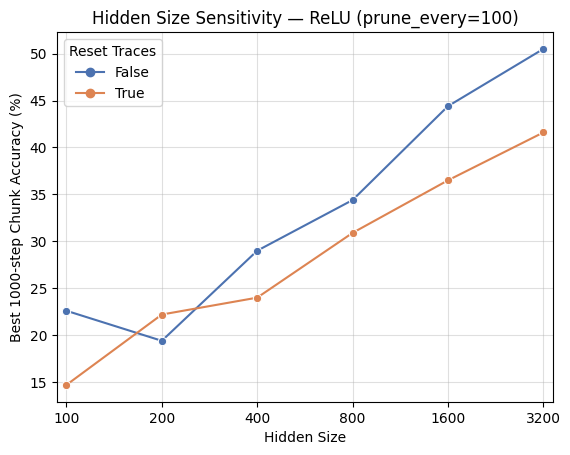

In [ ]:
plot_param_sensitivity(
    run_df=run_df_1_relu,
    config_df=config_df_1_relu,
    x_col='hidden_size',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Hidden Size Sensitivity — ReLU (prune_every=100)',
    x_label='Hidden Size',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)

## Experiment 1b: Hidden Size Sensitivity (LTU)

Same sweep as above but with the Linear Threshold Unit (step function forward, sigmoid gradient backward). LTU outputs are binary (0 or 1), so the utility signal may behave differently — units either fully contribute or not at all.

In [6]:
configs_exp1_ltu = [
    {'hidden_size': h, 'prune_every': 100, 'reset_traces_on_prune': r, 'activation': 'ltu'}
    for h, r in product(hidden_sizes, reset_values)
]

run_df_1_ltu, config_df_1_ltu = run_sweep(configs_exp1_ltu)

Sweep: 100%|██████████| 1260000/1260000 [01:45<00:00, 11940.45step/s, act=ltu, h=3200, p=100, reset=1]


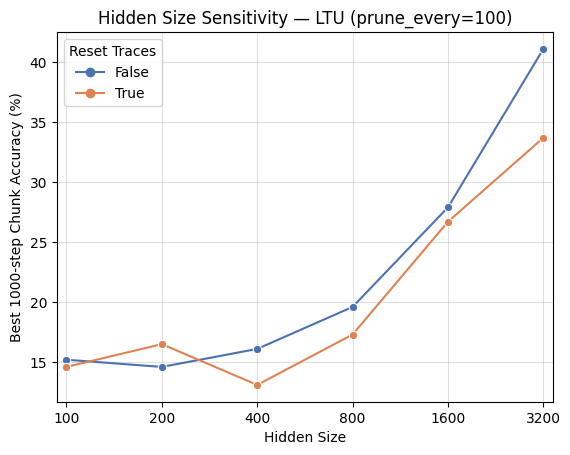

In [7]:
plot_param_sensitivity(
    run_df=run_df_1_ltu,
    config_df=config_df_1_ltu,
    x_col='hidden_size',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Hidden Size Sensitivity — LTU (prune_every=100)',
    x_label='Hidden Size',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)

## Experiment 2: Prune Frequency Sensitivity (ReLU)

How many steps should elapse between pruning events? Too few steps means the utility trace hasn't accumulated enough signal to make a good pruning decision; too many means we waste compute on units that could have been pruned earlier. Hidden size is fixed at 1000. Each point shows the best 1k-step chunk accuracy, with separate lines for reset vs. no-reset of utility traces after pruning.

In [ ]:
prune_every_values = [25, 50, 100, 200, 400, 800]

configs_exp2_relu = [
    {'hidden_size': 1000, 'prune_every': p, 'reset_traces_on_prune': r, 'activation': 'relu'}
    for p, r in product(prune_every_values, reset_values)
]

run_df_2_relu, config_df_2_relu = run_sweep(configs_exp2_relu)

Sweep: 100%|██████████| 3150000/3150000 [01:34<00:00, 33303.87step/s, act=relu, h=1000, p=800, reset=1]


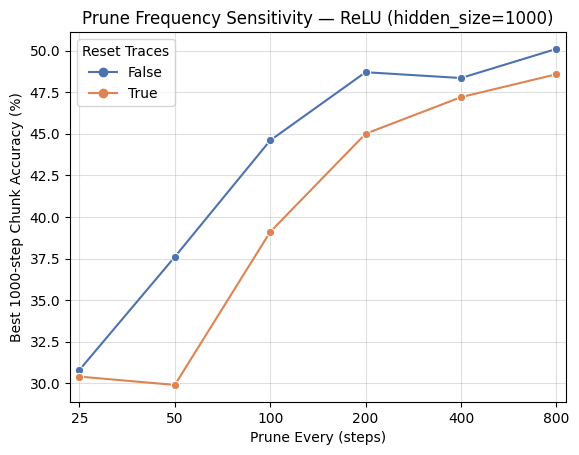

In [ ]:
plot_param_sensitivity(
    run_df=run_df_2_relu,
    config_df=config_df_2_relu,
    x_col='prune_every',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Prune Frequency Sensitivity — ReLU (hidden_size=1000)',
    x_label='Prune Every (steps)',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)

## Experiment 2b: Prune Frequency Sensitivity (LTU)

Same prune frequency sweep with LTU activation. Since LTU outputs are binary, the utility signal is simpler — a unit's contribution is either its full outgoing weight or zero. This may make the utility estimate more stable across different prune intervals.

In [ ]:
configs_exp2_ltu = [
    {'hidden_size': 1000, 'prune_every': p, 'reset_traces_on_prune': r, 'activation': 'ltu'}
    for p, r in product(prune_every_values, reset_values)
]

run_df_2_ltu, config_df_2_ltu = run_sweep(configs_exp2_ltu)

Sweep: 100%|██████████| 3150000/3150000 [01:32<00:00, 33898.34step/s, act=ltu, h=1000, p=800, reset=1]


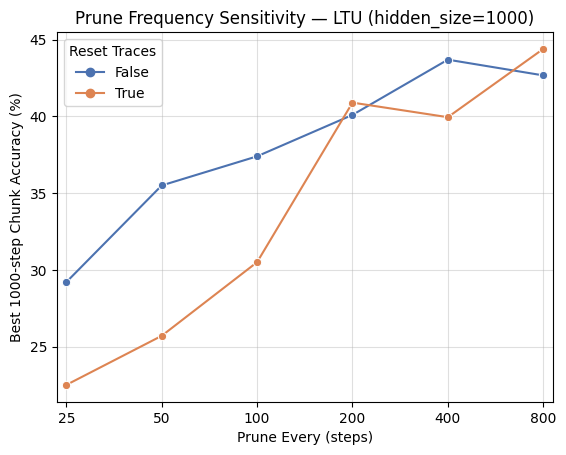

In [ ]:
plot_param_sensitivity(
    run_df=run_df_2_ltu,
    config_df=config_df_2_ltu,
    x_col='prune_every',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Prune Frequency Sensitivity — LTU (hidden_size=1000)',
    x_label='Prune Every (steps)',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)